In [ ]:
#import libraries
import numpy as np
import pandas as pd
import yfinance as yf
import seaborn as sns
from scipy.optimize import minimize
import matplotlib.pyplot as plt

%matplotlib inline

In [38]:
#Portfolio construction

TICKERS = [
    # --- 1. US EQUITIES (Sector Diversification) ---
    "MSFT",   # Technology (Software & Cloud)
    "NVDA",   # Technology (Semiconductors)
    "LLY",    # Healthcare / Pharmaceuticals
    "JPM",    # Financials / Investment Banking
    "AMZN",   # Consumer Cyclical / E-Commerce
    "PG",     # Consumer Defensive / Consumer Goods
    "XOM",    # Energy / Oil & Gas
    "CAT",    # Industrials / Heavy Machinery
    "NEE",    # Utilities / Renewable Energy
    "AMT",    # Real Estate (REIT / Telecom Towers)

    # --- 2. INTERNATIONAL EQUITIES (Geographic Diversification) ---
    "ASML",   # Europe (Netherlands) - Semi-cap Equipment
    "NSRGY",  # Europe (Switzerland) - Consumer Goods (Nestlé)
    "SAP",    # Europe (Germany) - Enterprise Software
    "TM",     # Asia (Japan) - Automotive (Toyota)
    "SONY",   # Asia (Japan) - Electronics & Entertainment
    "TSM",    # Asia (Taiwan) - Semiconductor Foundry
    "BABA",   # Emerging Markets (China) - Tech & Retail
    "HDB",    # Emerging Markets (India) - Banking & Finance
    "VALE",   # Emerging Markets (Brazil) - Materials & Mining
    "RY",     # North America (Canada) - Banking (Royal Bank)

    # --- 3. FIXED INCOME (Bonds for De-correlation) ---
    "TLT",    # US Long-Term Treasury Bonds (20+ Years)
    "IEF",    # US Intermediate-Term Treasury Bonds (7-10 Years)
    "TIP",    # US Inflation-Protected Treasury Bonds (TIPS)
    "BNDX",   # Total International Bond ETF (Non-US Hedged)
    "EMB",    # Emerging Markets Sovereign Bond ETF

    # --- 4. ALTERNATIVE ASSETS & COMMODITIES (Alternative Allocation) ---
    "GLD",    # Gold Shares (Traditional Safe Haven)
    "SLV",    # Silver Shares (Precious & Industrial Metal)
    "USO",    # United States Oil Fund (WTI Crude Oil)
    "DBA",    # Invesco Agricultural Fund (Corn, Wheat, Soy, Coffee)
    #"IBIT"    # iShares Bitcoin Trust (Spot Bitcoin ETF)
]



START = "2015-01-01"
END = "2025-01-01"
RF = 0.045  # Risk-free rate
PORTFOLIO_VALUE = 1_000_000  # Portfolio value
n = len(TICKERS)  # Number of tickers

#Data collection

df = yf.download(TICKERS, start=START, end=END, auto_adjust = True)['Close']
df.dropna(how='all', inplace=True)
df.ffill(inplace=True)  # forward-fill sporadic NaNs
df.dropna(inplace=True)

returns = df.pct_change().dropna()
print(f"{len(returns)} trading days of returns data collected for {n} assets from {START} to {END}.")

df.head()

[*********************100%***********************]  29 of 29 completed

2515 trading days of returns data collected for 29 assets from 2015-01-01 to 2025-01-01.


Ticker,AMT,AMZN,ASML,BABA,BNDX,CAT,DBA,EMB,GLD,HDB,...,SAP,SLV,SONY,TIP,TLT,TM,TSM,USO,VALE,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,75.034950,15.4260,96.068054,97.493027,38.525448,69.027153,21.180376,63.091366,114.080002,11.703402,...,57.984482,15.11,3.864589,82.318413,92.659264,93.269119,16.546331,159.119995,3.711830,57.145569
2015-01-05,73.950890,15.1095,92.838951,95.046295,38.510994,65.383438,21.438255,62.687351,115.800003,11.584073,...,55.633305,15.50,3.808199,82.384155,94.114815,91.562134,16.145296,150.320007,3.613658,55.581932
2015-01-06,73.755157,14.7645,90.092865,97.229530,38.597652,64.962761,21.584385,62.491138,117.120003,11.241841,...,54.374928,15.83,3.806319,82.391426,95.810524,90.619560,15.863083,144.399994,3.805326,55.286457
2015-01-07,74.530563,14.9210,90.602730,96.109680,38.568783,65.969460,21.481236,63.276020,116.430000,11.633604,...,53.886475,15.85,4.046916,82.457153,95.621307,92.898033,16.093309,146.960007,3.898824,55.846657
2015-01-08,75.223145,15.0230,92.499054,98.838737,38.554321,66.645599,21.403873,63.547272,115.940002,11.872268,...,54.747482,15.64,4.052555,82.325706,94.354980,94.686691,16.197281,148.399994,4.006346,56.776211


In [39]:
#Performance metrics
mean_returns = returns.mean()*252  # Annualized mean returns
volatility = returns.std()*np.sqrt(252)  # Annualized volatility
cov_matrix = returns.cov()*252  # Annualized covariance matrix

risk_df = pd.DataFrame({
    'Ann. Return' : mean_returns,
    'Ann. Volatility' : volatility,
    'Sharpe Ratio' : (mean_returns - RF) / volatility 
}).round(4)

print("Individual stock performance metrics:\n")
print(risk_df.to_string())

Individual stock performance metrics:

        Ann. Return  Ann. Volatility  Sharpe Ratio
Ticker                                            
AMT          0.1167           0.2553        0.2810
AMZN         0.3196           0.3278        0.8377
ASML         0.2644           0.3669        0.5979
BABA         0.0685           0.4164        0.0563
BNDX         0.0193           0.0406       -0.6323
CAT          0.2088           0.2976        0.5502
DBA          0.0278           0.1306       -0.1319
EMB          0.0317           0.0992       -0.1339
GLD          0.0854           0.1412        0.2860
HDB          0.1419           0.2911        0.3328
IEF          0.0081           0.0673       -0.5480
JPM          0.1991           0.2737        0.5632
LLY          0.2981           0.2787        0.9081
MSFT         0.2725           0.2714        0.8382
NEE          0.1544           0.2434        0.4496
NSRGY        0.0525           0.1737        0.0433
NVDA         0.6813           0.4861       

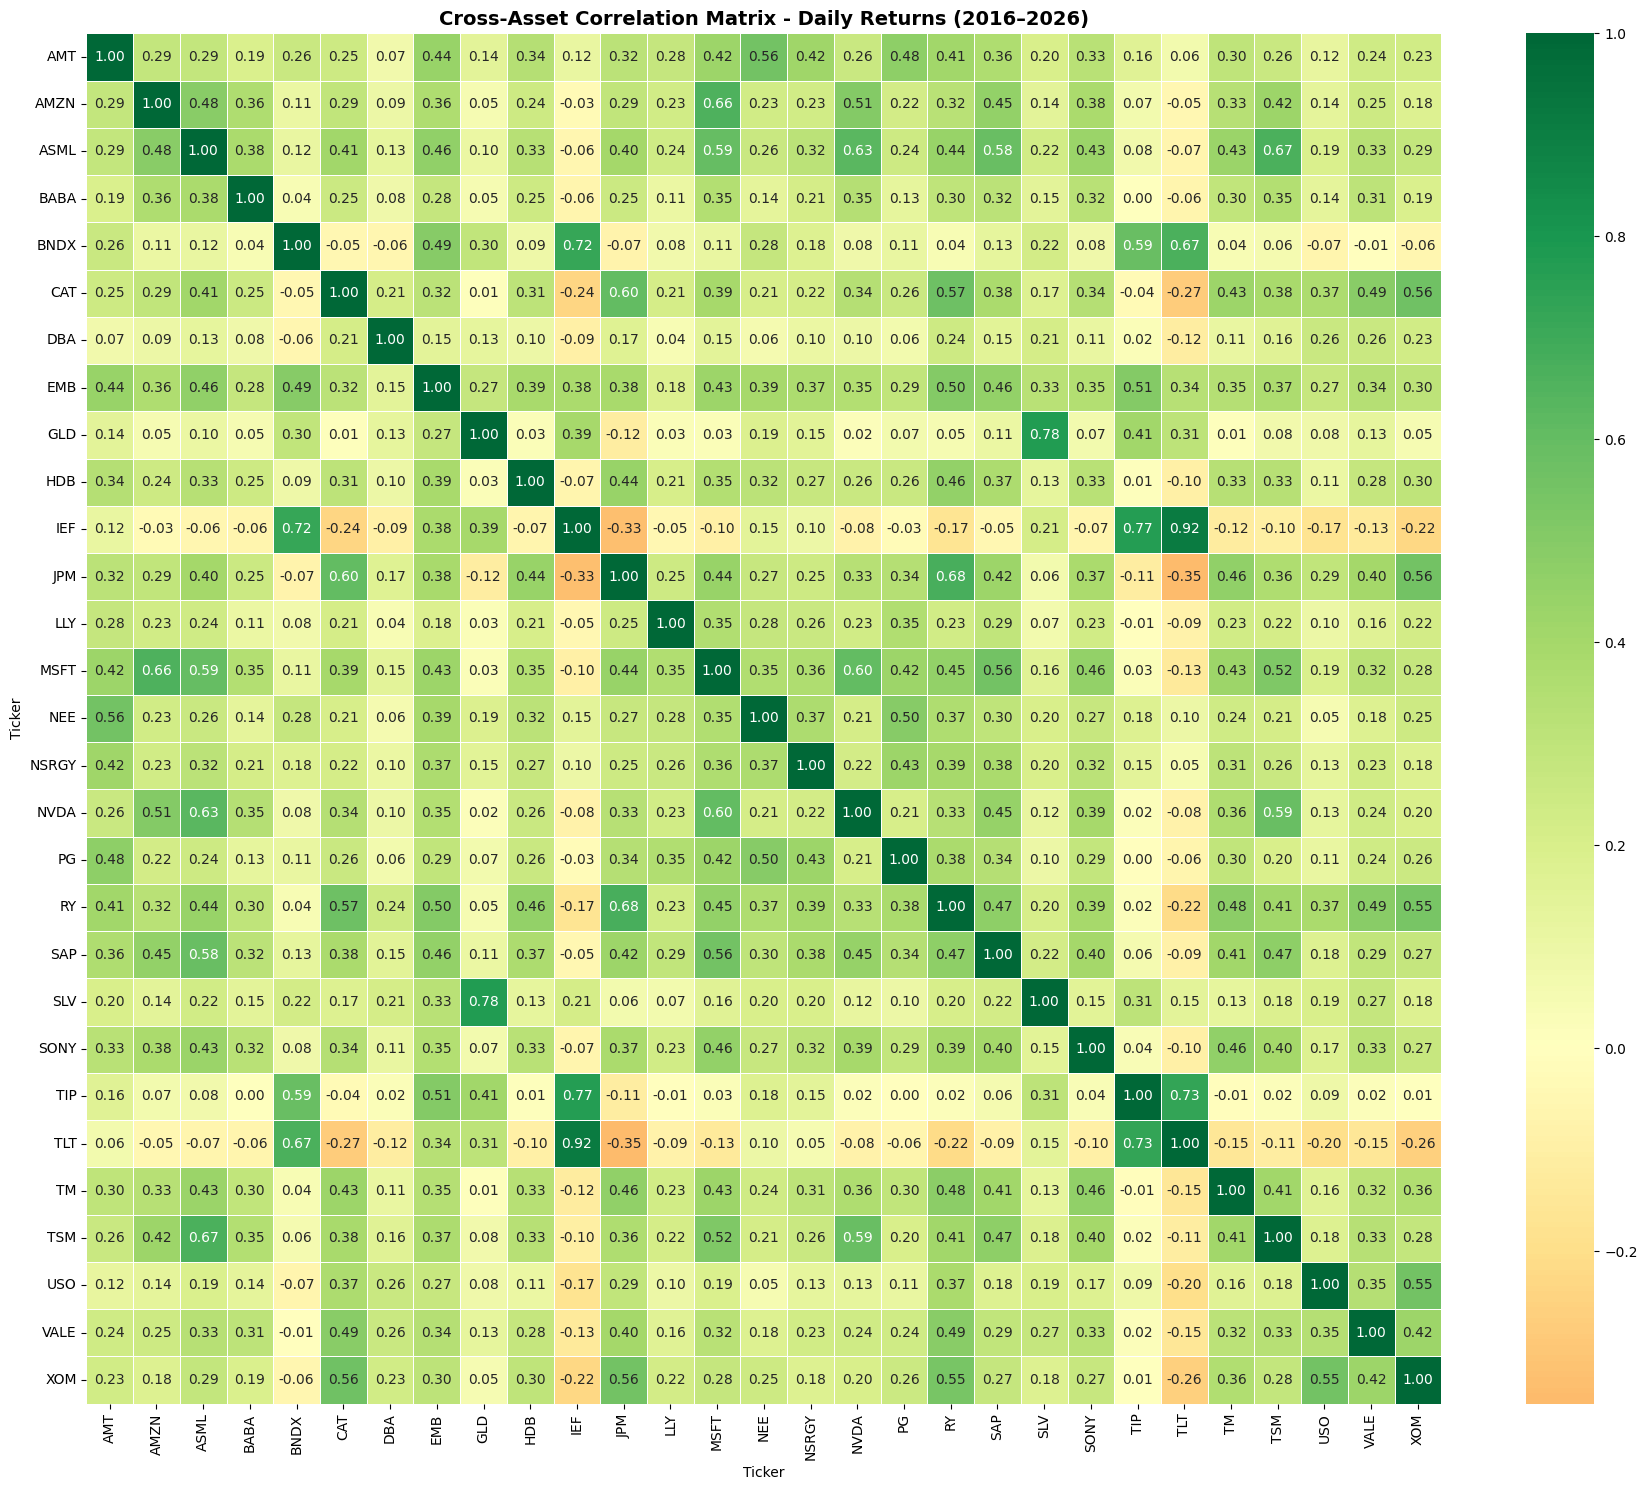

In [40]:
#Correlation heatmap
fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(returns.corr(), annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=ax, linewidths=0.5)

ax.set_title('Cross-Asset Correlation Matrix - Daily Returns (2016–2026)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [41]:
#We create an equal weight portfolio

weights_eq = np.array([1/n]*n)  # Equal weights for each asset
port_ret_eq = np.sum(returns.mean() * 252 * weights_eq)
port_vol_eq = np.sqrt(np.dot(weights_eq.T, np.dot(cov_matrix, weights_eq)))
sharpe_eq = (port_ret_eq - RF) / port_vol_eq

print(f"Portfolio Performance Metrics:\n")

print("="*45)
print(f" {'':20}{'Equal Weight Portfolio':>20}")
print(f"{'Expected Return': <20} {port_ret_eq:10.2%}")   
print(f"{'Volatility': <20} {port_vol_eq:10.2%}")
print(f"{'Sharpe Ratio': <20} {sharpe_eq:.2f}")
print("="*45)

Portfolio Performance Metrics:

                     Equal Weight Portfolio
Expected Return          15.05%
Volatility               13.78%
Sharpe Ratio         0.77


In [42]:
#Portfolio Optimization using scipy
#helper functions
def portfolio_return(weights):
    return np.sum(returns.mean() * 252 * weights)

def portfolio_volatility(weights):
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

def neg_sharpe(weights):
    return -(portfolio_return(weights) - RF) / portfolio_volatility(weights)

#constraints and bounds
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
bounds = tuple((0, 1) for _ in range(n))
init_guess = np.repeat(1/n, n)

#optimize for max Sharpe ratio
opt_sharpe = minimize(neg_sharpe, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)

w_optimal = opt_sharpe.x
returns_optimal = portfolio_return(w_optimal)
volatility_optimal = portfolio_volatility(w_optimal)
sharpe_optimal = (returns_optimal - RF) / volatility_optimal

#optimize for minimum volatility
opt_min_vol = minimize(portfolio_volatility, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)

w_min_volatility = opt_min_vol.x
returns_min_volatility = portfolio_return(w_min_volatility)
volatility_min_volatility = portfolio_volatility(w_min_volatility)
sharpe_min_volatility = (returns_min_volatility - RF) / volatility_min_volatility

print(f"Optimization complete using SLSQP.\n")
print(f"Max Sharpe Ratio Portfolio:")
print(f"  Expected Return: {returns_optimal:10.2%}")
print(f"  Volatility: {volatility_optimal:10.2%}")
print(f"  Sharpe Ratio: {sharpe_optimal:.2f}")


print(f"\nMinimum Volatility Portfolio:")
print(f"  Expected Return: {returns_min_volatility:10.2%}")
print(f"  Volatility: {volatility_min_volatility:10.2%}")   
print(f"  Sharpe Ratio: {sharpe_min_volatility:.2f}")

Optimization complete using SLSQP.

Max Sharpe Ratio Portfolio:
  Expected Return:     37.02%
  Volatility:     22.08%
  Sharpe Ratio: 1.47

Minimum Volatility Portfolio:
  Expected Return:      2.45%
  Volatility:      3.74%
  Sharpe Ratio: -0.55


In [43]:
# ----------------------------------------------- Daily portfolio returns  ---------------------------------------------------

#Max Sharpe Portfolio
port_returns = (returns * w_optimal).sum(axis=1)
var_results  = {}

print("  VALUE AT RISK & CVaR - Max Sharpe Portfolio")
print(f"    Portfolio value : €{PORTFOLIO_VALUE:,}\n")

for cl in [0.95, 0.99]:
    alpha    = 1 - cl
    var_pct  = np.percentile(port_returns, alpha * 100)
    cvar_pct = port_returns[port_returns <= var_pct].mean()
    var_results[cl] = {'var_pct': var_pct, 'cvar_pct': cvar_pct}

    print(f"   Confidence level : {cl:.0%}")
    print(f"   Historical VaR   : {var_pct:.2%}  (= €{var_pct * PORTFOLIO_VALUE:,.0f})")
    print(f"   Historical CVaR  : {cvar_pct:.2%}  (= €{cvar_pct * PORTFOLIO_VALUE:,.0f})")
    print()

#Minimum Volatility Portfolio
port_returns_min_vol = (returns * w_min_volatility).sum(axis=1) 
var_results_min_vol  = {}

print("  VALUE AT RISK & CVaR - Minimum Volatility Portfolio")
print(f"    Portfolio value : €{PORTFOLIO_VALUE:,}\n")

for cl in [0.95, 0.99]:
    alpha    = 1 - cl
    var_pct  = np.percentile(port_returns_min_vol, alpha * 100)
    cvar_pct = port_returns_min_vol[port_returns_min_vol <= var_pct].mean()
    var_results_min_vol[cl] = {'var_pct': var_pct, 'cvar_pct': cvar_pct}

    print(f"   Confidence level : {cl:.0%}")
    print(f"   Historical VaR   : {var_pct:.2%}  (= €{var_pct * PORTFOLIO_VALUE:,.0f})")
    print(f"   Historical CVaR  : {cvar_pct:.2%}  (= €{cvar_pct * PORTFOLIO_VALUE:,.0f})")
    print()

# Equal-Weight Portfolio
port_returns_eq = (returns * weights_eq).sum(axis=1)
var_results_eq = {}

print("  VALUE AT RISK & CVaR - Equal-Weight Portfolio")
print(f"    Portfolio value : €{PORTFOLIO_VALUE:,}\n")

for cl in [0.95, 0.99]:
    alpha    = 1 - cl
    var_pct  = np.percentile(port_returns_eq, alpha * 100)
    cvar_pct = port_returns_eq[port_returns_eq <= var_pct].mean()
    var_results_eq[cl] = {'var_pct': var_pct, 'cvar_pct': cvar_pct}

    print(f"   Confidence level : {cl:.0%}")
    print(f"   Historical VaR   : {var_pct:.2%}  (= €{var_pct * PORTFOLIO_VALUE:,.0f})")
    print(f"   Historical CVaR  : {cvar_pct:.2%}  (= €{cvar_pct * PORTFOLIO_VALUE:,.0f})")
    print()

  VALUE AT RISK & CVaR - Max Sharpe Portfolio
    Portfolio value : €1,000,000

   Confidence level : 95%
   Historical VaR   : -2.03%  (= €-20,337)
   Historical CVaR  : -2.95%  (= €-29,534)

   Confidence level : 99%
   Historical VaR   : -3.38%  (= €-33,759)
   Historical CVaR  : -4.48%  (= €-44,821)

  VALUE AT RISK & CVaR - Minimum Volatility Portfolio
    Portfolio value : €1,000,000

   Confidence level : 95%
   Historical VaR   : -0.37%  (= €-3,673)
   Historical CVaR  : -0.54%  (= €-5,422)

   Confidence level : 99%
   Historical VaR   : -0.59%  (= €-5,919)
   Historical CVaR  : -0.89%  (= €-8,881)

  VALUE AT RISK & CVaR - Equal-Weight Portfolio
    Portfolio value : €1,000,000

   Confidence level : 95%
   Historical VaR   : -1.30%  (= €-13,010)
   Historical CVaR  : -1.98%  (= €-19,814)

   Confidence level : 99%
   Historical VaR   : -2.28%  (= €-22,779)
   Historical CVaR  : -3.39%  (= €-33,915)



[*********************100%***********************]  1 of 1 completed

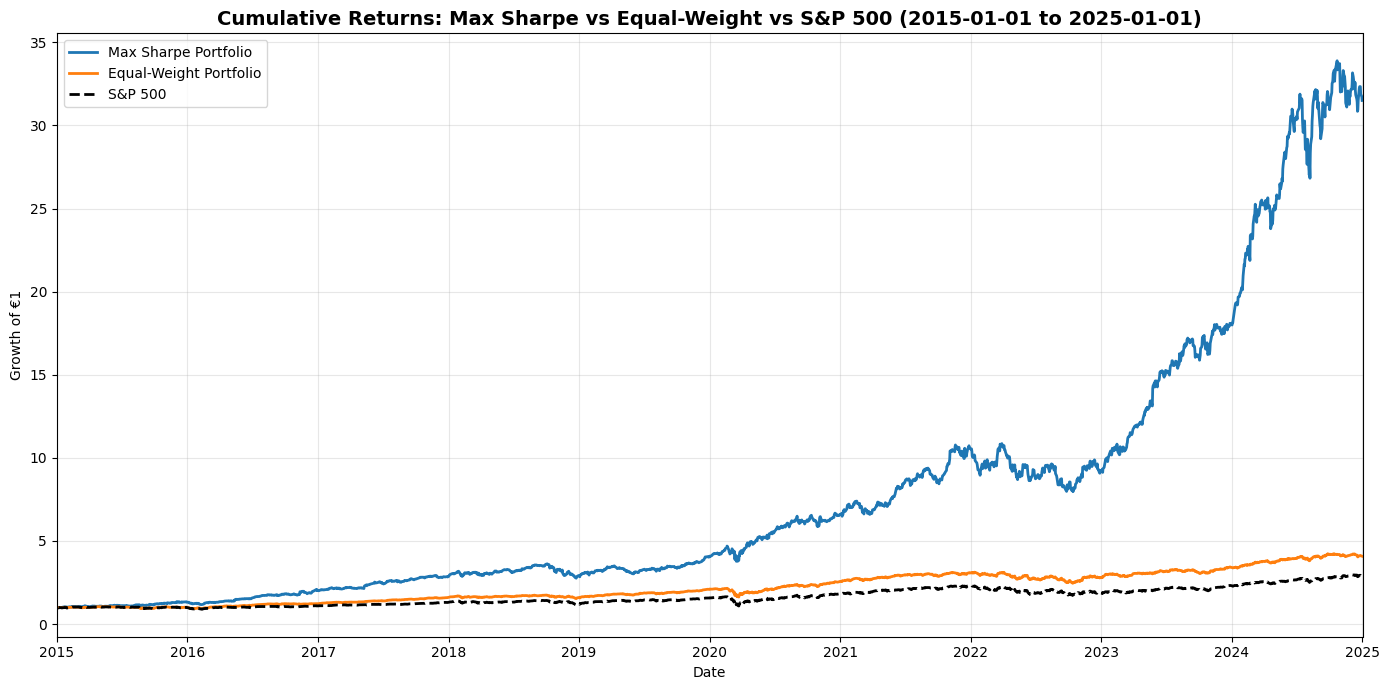

In [44]:
# visualization of the cumulative returns of the Max Sharpe, Equal-Weight  and the SP500 portfolios

#S&P 500 benchmark data, over the full START-END window
sp500 = yf.download("^GSPC", start=START, end=END, auto_adjust=True)['Close'].squeeze()
sp500_returns = sp500.pct_change().dropna()
sp500_returns = sp500_returns.reindex(returns.index).dropna()

#cumulative growth of €1
cum_max_sharpe = (1 + port_returns).cumprod()
cum_eq         = (1 + port_returns_eq).cumprod()
cum_sp500      = (1 + sp500_returns).cumprod()

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(cum_max_sharpe.index, cum_max_sharpe, label='Max Sharpe Portfolio', linewidth=2)
ax.plot(cum_eq.index, cum_eq, label='Equal-Weight Portfolio', linewidth=2)
ax.plot(cum_sp500.index, cum_sp500, label='S&P 500', linewidth=2, linestyle='--', color='black')

ax.set_title(f'Cumulative Returns: Max Sharpe vs Equal-Weight vs S&P 500 ({START} to {END})',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Growth of €1')
ax.set_xlabel('Date')
ax.set_xlim(pd.to_datetime(START), pd.to_datetime(END))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [45]:
#summary of the results

summary_df = pd.DataFrame({
    'Max Sharpe' : {
        'Expected Return' : returns_optimal,
        'Volatility'      : volatility_optimal,
        'Sharpe Ratio'    : sharpe_optimal,
        'VaR (95%)'       : var_results[0.95]['var_pct'],
        'CVaR (95%)'      : var_results[0.95]['cvar_pct'],
    },
    'Min Volatility' : {
        'Expected Return' : returns_min_volatility,
        'Volatility'      : volatility_min_volatility,
        'Sharpe Ratio'    : sharpe_min_volatility,
        'VaR (95%)'       : var_results_min_vol[0.95]['var_pct'],
        'CVaR (95%)'      : var_results_min_vol[0.95]['cvar_pct'],
    },
    'Equal Weight' : {
        'Expected Return' : port_ret_eq,
        'Volatility'      : port_vol_eq,
        'Sharpe Ratio'    : sharpe_eq,
        'VaR (95%)'       : var_results_eq[0.95]['var_pct'],
        'CVaR (95%)'      : var_results_eq[0.95]['cvar_pct'],
    }
}).T

print("PORTFOLIO SUMMARY\n")
print(summary_df.to_string(formatters={
    'Expected Return' : '{:.2%}'.format,
    'Volatility'      : '{:.2%}'.format,
    'Sharpe Ratio'    : '{:.2f}'.format,
    'VaR (95%)'       : '{:.2%}'.format,
    'CVaR (95%)'      : '{:.2%}'.format,
}))

top_holdings = pd.Series(w_optimal, index=TICKERS).sort_values(ascending=False)
print(f"\nTop 5 holdings - Max Sharpe Portfolio:\n")
print(top_holdings.head(5).apply(lambda x: f"{x:.2%}").to_string())

PORTFOLIO SUMMARY

               Expected Return Volatility Sharpe Ratio VaR (95%) CVaR (95%)
Max Sharpe              37.02%     22.08%         1.47    -2.03%     -2.95%
Min Volatility           2.45%      3.74%        -0.55    -0.37%     -0.54%
Equal Weight            15.05%     13.78%         0.77    -1.30%     -1.98%

Top 5 holdings - Max Sharpe Portfolio:

BABA     33.52%
SAP      32.69%
NEE      25.91%
NVDA      5.46%
NSRGY     2.42%
